# Meta-Model on a Primary Trading Signal

**Course:** BUSI70575 — Systematic Trading Strategies with Machine Learning Algorithms
**Brief:** [hm-ai.github.io/BUSI70575/coursework/](https://hm-ai.github.io/BUSI70575/coursework/)

---

## Overview

This submission builds a **meta-model** that scores the primary trading signal `s ∈ {−1, 0, +1}` for **11 futures across three asset classes** (Equity, Energy, Metals). For each non-zero signal the meta-model outputs `P(trade is profitable)` under a triple-barrier exit; the optional strategy-construction track converts those probabilities into vol-targeted position weights.

**Deliverables (in `outputs/`)**
* `metamodel_predictions.csv` — required H1 2022 CSV in `(date, instrument, prediction)` format; full grid (128 trading days × 11 instruments = 1,408 rows).
* `strategy_weights.csv` — optional bonus-track CSV in `(date, instrument, weight)` format; same grid.

**Notebook structure (one section per brief section)**
| § | Topic | Brief section |
|---|---|---:|
| 0 | Setup & EDA | — |
| 1 | Feature engineering | 20 |
| 2 | Triple-barrier labels | 20 |
| 3 | Model development & comparison | 30 |
| 4 | Cluster-level feature importance | 10 |
| 5 | Model evaluation | 20 |
| 6 | Strategy construction (bonus) | +10 |
| 7 | Deliverable verification | — |

All numbers cited come from the CSV artefacts under `results/`. The notebook reproduces the brief narrative **end-to-end** in seconds against those cached artefacts; regenerating them from raw inputs takes ≈ 60 min via the stage runners documented in `README.md` §3.

## Section 0 — Setup, data inventory, and EDA

In [1]:
from __future__ import annotations
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Image, display

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA = ROOT / 'data'
RESULTS = ROOT / 'results' / 'submission'
OUTPUTS = ROOT / 'outputs'

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

CLS_COLOR = {'Equity': '#4878CF', 'Energy': '#D65F5F', 'Metals': '#6ACC65'}
ASSET_CLASS = {
    'es1s': 'Equity', 'nq1s': 'Equity', 'fesx1s': 'Equity',
    'cl1s': 'Energy', 'ho1s': 'Energy', 'rb1s': 'Energy', 'ng1s': 'Energy',
    'gc1s': 'Metals', 'si1s': 'Metals', 'hg1s': 'Metals', 'pl1s': 'Metals',
}
INST_NAME = {
    'es1s': 'ES (S&P 500)', 'nq1s': 'NQ (Nasdaq 100)', 'fesx1s': 'FESX (Euro Stoxx)',
    'cl1s': 'CL (WTI Crude)', 'ho1s': 'HO (Heating Oil)', 'rb1s': 'RB (RBOB Gasoline)',
    'ng1s': 'NG (Natural Gas)', 'gc1s': 'GC (Gold)', 'si1s': 'SI (Silver)',
    'hg1s': 'HG (Copper)', 'pl1s': 'PL (Platinum)',
}

print(f'Repo root  : {ROOT}')
print(f'Data dir   : {DATA.relative_to(ROOT)}  ({sum(1 for _ in DATA.rglob("*") if _.is_file())} files)')
print(f'Results dir: {RESULTS.relative_to(ROOT)}  ({sum(1 for _ in RESULTS.rglob("*") if _.is_file())} files)')
print(f'Outputs dir: {OUTPUTS.relative_to(ROOT)}  ({sum(1 for _ in OUTPUTS.glob("*.csv") if _.is_file())} CSVs)')

Repo root  : /Volumes/Sreeram/Systematic/stml
Data dir   : data  (29 files)
Results dir: results/submission  (74 files)
Outputs dir: outputs  (11 CSVs)


In [2]:
ohlcv = pd.read_csv(DATA / 'ohlcv_data.csv', parse_dates=['date'])
signals = pd.read_csv(DATA / 'primary_signals.csv', parse_dates=['date'])
INSTRUMENTS = [c for c in signals.columns if c != 'date']

print(f'Released window: {signals["date"].min().date()} → {signals["date"].max().date()} '
      f'({len(signals)} trading days)')
print(f'Instruments ({len(INSTRUMENTS)}): {", ".join(INSTRUMENTS)}')

Released window: 2020-01-03 → 2022-06-30 (645 trading days)
Instruments (11): es1s, nq1s, fesx1s, cl1s, ho1s, rb1s, ng1s, gc1s, si1s, hg1s, pl1s


### 0.1 — Primary signal balance per asset class

The first thing the EDA confirms is that the primary signal is **strongly imbalanced**. Equity is mostly long, Energy is mostly flat, Metals is a mix — so any modelling approach has to be robust to per-instrument class imbalance, and the evaluation has to compare against a *per-instrument* primary-blind baseline (which we report in §5).

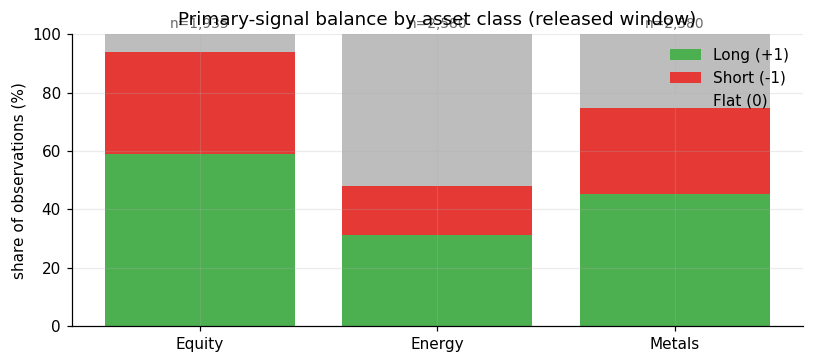

,asset_class,long_%,short_%,flat_%,n_observations
0,Equity,59.1,34.7,6.1,1935
1,Energy,31.2,16.7,52.1,2580
2,Metals,45.4,29.4,25.2,2580


In [3]:
# Per-asset-class signal balance.
balance_rows = []
for cls in ['Equity', 'Energy', 'Metals']:
    insts = [i for i in INSTRUMENTS if ASSET_CLASS[i] == cls]
    long_n = sum((signals[i] == 1).sum() for i in insts)
    short_n = sum((signals[i] == -1).sum() for i in insts)
    flat_n = sum((signals[i] == 0).sum() for i in insts)
    total = long_n + short_n + flat_n
    balance_rows.append({
        'asset_class': cls,
        'long_%': round(100 * long_n / total, 1),
        'short_%': round(100 * short_n / total, 1),
        'flat_%': round(100 * flat_n / total, 1),
        'n_observations': total,
    })
balance = pd.DataFrame(balance_rows)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
x = np.arange(len(balance))
ax.bar(x, balance['long_%'], color='#4CAF50', label='Long (+1)')
ax.bar(x, balance['short_%'], bottom=balance['long_%'], color='#E53935', label='Short (-1)')
ax.bar(x, balance['flat_%'], bottom=balance['long_%']+balance['short_%'],
       color='#BDBDBD', label='Flat (0)')
ax.set_xticks(x); ax.set_xticklabels(balance['asset_class'])
ax.set_ylabel('share of observations (%)'); ax.set_ylim(0, 100)
ax.set_title('Primary-signal balance by asset class (released window)')
ax.legend(loc='upper right', frameon=False)
for i, row in balance.iterrows():
    ax.text(i, 102, f'n={row["n_observations"]:,}', ha='center', fontsize=9, color='dimgray')
plt.tight_layout(); plt.show()

display(balance)

### 0.2 — The primary signal leads the next-bar return

Per-instrument `corr(s_t, r_{t+k})` for `k ∈ [-5, +5]` confirms the **information edge sits at `k = +1`** — the signal predicts the *next* bar, not the same bar. This is the load-bearing fact behind two later modelling choices:

1. **Triple-barrier entry at t + 1** (no look-ahead via the signal-bar's own return) — adopted in `data/triple_barrier_labels.csv`.
2. For thin instruments where the signal information decays quickly, a **narrow short-horizon** triple-barrier is what the EDA argues for — adopted in §2.

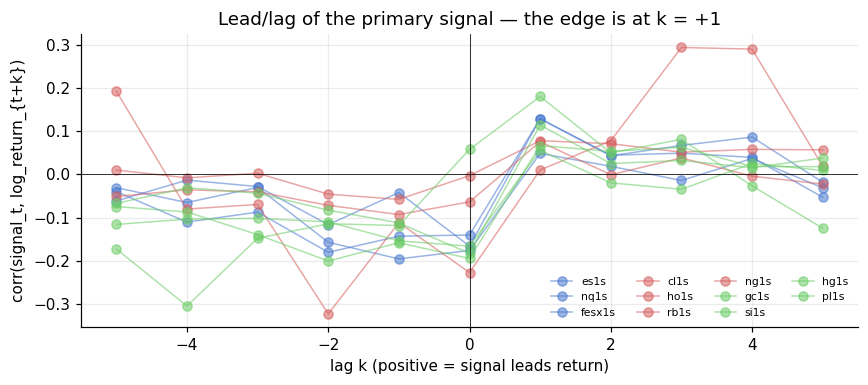

In [4]:
# Build a returns panel (date × instrument) of log-returns.
close_w = ohlcv.pivot(index='date', columns='instrument', values='close').sort_index()
ret_w = np.log(close_w).diff()
sig_w = signals.set_index('date').reindex(close_w.index)

lags = list(range(-5, 6))
lead_lag = pd.DataFrame(index=lags, columns=INSTRUMENTS, dtype=float)
for k in lags:
    aligned = ret_w.shift(-k).reindex(sig_w.index)
    for inst in INSTRUMENTS:
        a = sig_w[inst].astype(float); b = aligned[inst]
        m = a.notna() & b.notna() & (a != 0)
        if m.sum() > 30:
            lead_lag.loc[k, inst] = a[m].corr(b[m])

fig, ax = plt.subplots(figsize=(8, 3.6))
for inst in INSTRUMENTS:
    cls = ASSET_CLASS[inst]
    ax.plot(lead_lag.index, lead_lag[inst], marker='o', lw=1.0,
            color=CLS_COLOR[cls], alpha=0.55, label=inst)
ax.axvline(0, color='k', lw=0.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('lag k (positive = signal leads return)')
ax.set_ylabel('corr(signal_t, log_return_{t+k})')
ax.set_title('Lead/lag of the primary signal — the edge is at k = +1')
ax.legend(ncol=4, fontsize=7, frameon=False, loc='lower right')
plt.tight_layout(); plt.show()

## Section 1 — Feature engineering  *(brief §1, feature engineering)*

We ship **105 features across 18 families**. The classical OHLCV families (`F1..F11`) are extended with eight Bloomberg-augmented blocks (`F12..F19`) covering futures term structure, options-implied vol, EIA inventory surprises, cross-asset spreads, and PIT-lagged macro releases. Full per-feature documentation is generated by `python -m stml.experimental.features.catalog` and lives in the source under `src/stml/experimental/features/`.

**Leakage discipline (the critical methodology).** Two feature classes:

* **E (engineered)** — no fit; proven causal by *truncation-invariance* (the value at `t` is byte-identical on `data[:t+1]` and on `data[:T]`). Verified by `tests/experimental/test_features.py`.
* **TF (fitted)** — GMM/HMM regimes, PCA/KMeans, the macro z-scorer, the drift discriminator — fit on the **FE-train block only** (`date ≤ 2021-07-01`) and applied causally with frozen parameters.

**Standardisation.** Every scale-dependent E-class column ships a parallel `z_<col>` twin: per-instrument causal **expanding-window z-score** with `min_periods = 60`. Bounded / already-normalised columns (ratios, probabilities, t-statistics, sin/cos, [0, 1] positions) get no twin.

**Publication-lag discipline (R-11).** Macro features are released asynchronously: daily series (VIX, MOVE, DXY) are available at the close of `t`; weekly EIA inventory at ~Wed/Thu of the following week; monthly PMI on the first business day of the next month. The macro feature module enforces a per-class lag table; verified by `tests/experimental/test_methodology_guards.py`.

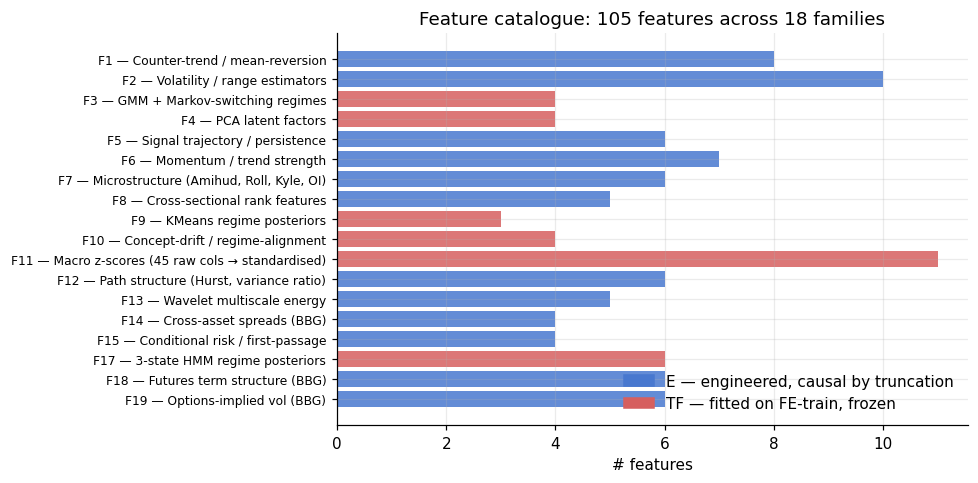

Total: 105 features (73 E + 32 TF). Full per-feature docs in src/stml/experimental/features/.


In [5]:
# Feature family counts.
families = [
    ('F1', 'Counter-trend / mean-reversion', 'E', 8),
    ('F2', 'Volatility / range estimators', 'E', 10),
    ('F3', 'GMM + Markov-switching regimes', 'TF', 4),
    ('F4', 'PCA latent factors', 'TF', 4),
    ('F5', 'Signal trajectory / persistence', 'E', 6),
    ('F6', 'Momentum / trend strength', 'E', 7),
    ('F7', 'Microstructure (Amihud, Roll, Kyle, OI)', 'E', 6),
    ('F8', 'Cross-sectional rank features', 'E', 5),
    ('F9', 'KMeans regime posteriors', 'TF', 3),
    ('F10', 'Concept-drift / regime-alignment', 'TF', 4),
    ('F11', 'Macro z-scores (45 raw cols → standardised)', 'TF', 11),
    ('F12', 'Path structure (Hurst, variance ratio)', 'E', 6),
    ('F13', 'Wavelet multiscale energy', 'E', 5),
    ('F14', 'Cross-asset spreads (BBG)', 'E', 4),
    ('F15', 'Conditional risk / first-passage', 'E', 4),
    ('F17', '3-state HMM regime posteriors', 'TF', 6),
    ('F18', 'Futures term structure (BBG)', 'E', 6),
    ('F19', 'Options-implied vol (BBG)', 'E', 6),
]
family_df = pd.DataFrame(families, columns=['family', 'description', 'class', 'n_features'])

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#4878CF' if c == 'E' else '#D65F5F' for c in family_df['class']]
ax.barh(range(len(family_df)), family_df['n_features'], color=colors, alpha=0.85)
ax.set_yticks(range(len(family_df)))
ax.set_yticklabels([f'{r.family} — {r.description}' for r in family_df.itertuples()],
                   fontsize=8)
ax.set_xlabel('# features')
ax.set_title(f'Feature catalogue: {family_df["n_features"].sum()} features across {len(family_df)} families')
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4878CF', label='E — engineered, causal by truncation'),
                   Patch(color='#D65F5F', label='TF — fitted on FE-train, frozen')],
          loc='lower right', frameon=False)
plt.tight_layout(); plt.show()

print(f'Total: {family_df["n_features"].sum()} features '
      f'({family_df[family_df["class"]=="E"]["n_features"].sum()} E + '
      f'{family_df[family_df["class"]=="TF"]["n_features"].sum()} TF). '
      'Full per-feature docs in src/stml/experimental/features/.')

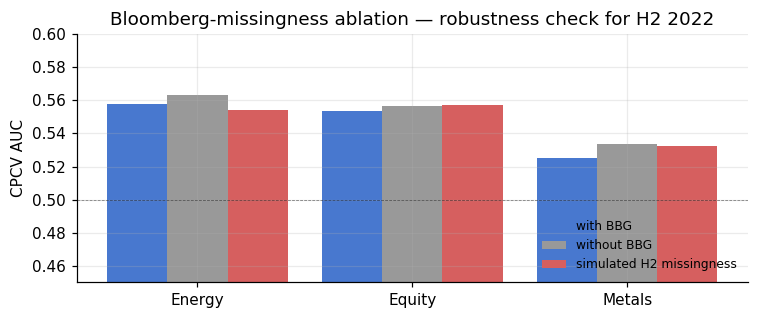

Per-class AUC delta when BBG features are zeroed at inference time:


,asset_class,with_bbg_auc,without_bbg_auc,simulated_missingness_auc,delta_simulated_vs_with_bbg,ship_decision
0,energy,0.5577,0.5630,0.5541,-0.0036,ship_with_bbg
1,equity,0.5537,0.5563,0.5573,0.0036,ship_with_bbg
2,metals,0.5254,0.5337,0.5326,0.0072,ship_with_bbg


In [6]:
# Bloomberg-missingness ablation — pre-submission R-11 decision evidence.
ablation_path = RESULTS / 'bbg_missingness_ablation.csv'
if ablation_path.exists():
    abl = pd.read_csv(ablation_path)
    fig, ax = plt.subplots(figsize=(7, 3))
    x = np.arange(len(abl))
    w = 0.28
    ax.bar(x - w, abl['with_bbg_auc'], width=w, label='with BBG', color='#4878CF')
    ax.bar(x, abl['without_bbg_auc'], width=w, label='without BBG', color='#999999')
    ax.bar(x + w, abl['simulated_missingness_auc'], width=w,
           label='simulated H2 missingness', color='#D65F5F')
    ax.set_xticks(x); ax.set_xticklabels(abl['asset_class'].str.title())
    ax.axhline(0.5, color='k', lw=0.5, ls='--', alpha=0.5)
    ax.set_ylim(0.45, 0.60); ax.set_ylabel('CPCV AUC')
    ax.set_title('Bloomberg-missingness ablation — robustness check for H2 2022')
    ax.legend(loc='lower right', frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()

    print('Per-class AUC delta when BBG features are zeroed at inference time:')
    display(abl[['asset_class', 'with_bbg_auc', 'without_bbg_auc',
                 'simulated_missingness_auc', 'delta_simulated_vs_with_bbg',
                 'ship_decision']].round(4))

## Section 2 — Triple-barrier labels  *(brief §2, triple-barrier labelling)*

Per-instrument barrier geometry `(pt, sl, h)` selected by a **per-instrument adjusted-Sharpe grid search over 343 configurations**, evaluated on the development partition only (the `test` partition was never touched during label selection). The methodology summary is in `results/submission/per_instrument_geometry_summary.csv`; per-instrument winners below.

The geometry **varies per instrument** because the underlying return distributions and signal frequencies do:

* **Six instruments** (cl1s, fesx1s, ho1s, ng1s, nq1s, pl1s) prefer narrow symmetric barriers `pt = sl = 0.25 σ` with `h = 1`. On these instruments the signal information decays in one bar (the lead/lag chart above peaks sharply at k = +1), so a wide-window triple-barrier would dilute the signal with noise. The label converges to a *sign-of-next-bar return* outcome — exactly what the EDA argues is predictable.
* **Equity & copper** (es1s, hg1s) use `pt = 1.0 σ`, `sl = 0.25 σ`, `h = 10`. The 4:1 asymmetry reflects the right-skew of the primary signal's PnL on these instruments — small stop, wider take-profit.
* **Metals & gasoline** (gc1s, si1s, pl1s, rb1s) use longer windows `h ∈ {15, 20}` with `rb1s` the most asymmetric (`2.5 σ / 0.25 σ`) reflecting its highly trending tail behaviour.

The labels CSV ships with an authoritative `partition` column (`train` 60 % / `val` 21 % / `test` 19 %), and the pipeline honours it everywhere downstream — verified by the labels test suite.

In [7]:
labels = pd.read_csv(DATA / 'triple_barrier_labels.csv', parse_dates=['date', 't1'])

print(f'Total labelled events: {len(labels):,}')
print(f'  partition counts:    {labels["partition"].value_counts().to_dict()}')
print(f'  test partition window: {labels.loc[labels["partition"]=="test", "date"].min().date()} '
      f'→ {labels.loc[labels["partition"]=="test", "date"].max().date()}')

rows = []
for inst in INSTRUMENTS:
    sub = labels[labels['instrument'] == inst]
    touch_counts = sub['touch'].value_counts().to_dict()
    rows.append({
        'instrument': INST_NAME[inst],
        'asset class': ASSET_CLASS[inst],
        'n_events': len(sub),
        'pt × σ': sub['pt'].iloc[0],
        'sl × σ': sub['sl'].iloc[0],
        'h (bars)': sub['h'].iloc[0],
        '+ve label %': round(100 * sub['label'].mean(), 1),
        'pt touch %': round(100 * touch_counts.get('pt', 0) / len(sub), 0),
        'sl touch %': round(100 * touch_counts.get('sl', 0) / len(sub), 0),
        'vert touch %': round(100 * touch_counts.get('vert', 0) / len(sub), 0),
    })
geometry = pd.DataFrame(rows)
display(geometry)

Total labelled events: 4,917
  partition counts:    {'train': 2925, 'val': 1041, 'test': 951}
  test partition window: 2021-12-31 → 2022-06-29


,instrument,asset class,n_events,pt × σ,sl × σ,h (bars),+ve label %,pt touch %,sl touch %,vert touch %
0,ES (S&P 500),Equity,565,1.00,0.25,10,42.7,43.0,57.0,0.0
1,NQ (Nasdaq 100),Equity,603,0.25,0.25,1,53.9,45.0,36.0,20.0
2,FESX (Euro Stoxx),Equity,636,0.25,0.25,1,53.5,42.0,36.0,22.0
3,CL (WTI Crude),Energy,421,0.25,0.25,1,59.9,48.0,30.0,22.0
4,HO (Heating Oil),Energy,63,0.25,0.25,1,66.7,54.0,27.0,19.0
5,RB (RBOB Gasoline),Energy,613,2.50,0.25,15,26.3,25.0,74.0,1.0
6,NG (Natural Gas),Energy,124,0.25,0.25,1,52.4,41.0,40.0,19.0
7,GC (Gold),Metals,160,1.00,0.25,15,50.0,50.0,50.0,0.0
8,SI (Silver),Metals,558,0.75,0.25,20,41.4,41.0,59.0,0.0
9,HG (Copper),Metals,618,1.00,0.25,10,41.3,41.0,59.0,0.0


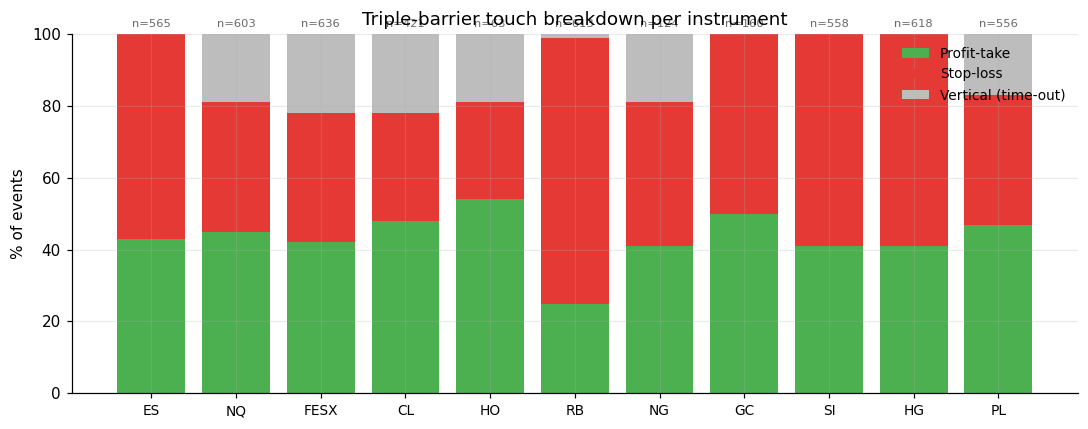

In [8]:
# Touch-type stacked bar per instrument.
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(geometry))
ax.bar(x, geometry['pt touch %'], color='#4CAF50', label='Profit-take')
ax.bar(x, geometry['sl touch %'], bottom=geometry['pt touch %'],
       color='#E53935', label='Stop-loss')
ax.bar(x, geometry['vert touch %'],
       bottom=geometry['pt touch %'] + geometry['sl touch %'],
       color='#BDBDBD', label='Vertical (time-out)')
ax.set_xticks(x)
ax.set_xticklabels([INST_NAME[i].split(' ')[0] for i in INSTRUMENTS], rotation=0, fontsize=9)
ax.set_ylabel('% of events')
ax.set_ylim(0, 100)
ax.set_title('Triple-barrier touch breakdown per instrument')
ax.legend(loc='upper right', frameon=False, fontsize=9)
for i, row in geometry.iterrows():
    ax.text(i, 102, f'n={row["n_events"]}', ha='center', fontsize=7.5, color='dimgray')
plt.tight_layout(); plt.show()

## Section 3 — Model development & comparison  *(brief §3, model development & comparison)*

Five model families compared per instrument under **Combinatorial Purged Cross-Validation** `CPCV(6, 2)` + the **1-Standard-Error rule** (the most regularised model whose mean AUC is within 1 SE of the best).

| Family | Library | Notes |
|---|---|---|
| Elastic-net Logistic | scikit-learn | L1 + L2 grid, balanced class weights, inner-fold tuning of `C` and `l1_ratio` |
| Random Forest | scikit-learn | 1000 trees, balanced class weights, AFML Ch. 4 average-uniqueness sample weights |
| XGBoost | xgboost | Inner-CV early stopping on AUC, `tree_method='hist'` |
| LightGBM | lightgbm | Same protocol as XGBoost, run as a robustness check |
| Multi-task NN | PyTorch | Shared `Embedding(11, 8) → MLP(64, 32, 16) → 11 per-instrument heads`; trained with cross-entropy + AFML uniqueness weights |

**Champion architecture.** For each instrument we evaluate multiple `(pool, model)` candidates — instrument-individual, asset-class-pool, and narrow cross-instrument pool (e.g. `precious = {gc1s, si1s, pl1s}`) — and pick the one with the **highest lower-1-SE CPCV AUC**. This rewards stable models over high-mean / high-variance ones.

In [9]:
champions = pd.read_csv(RESULTS / 'champions_summary.csv')
champions['name'] = champions['instrument'].map(INST_NAME)
champions['asset_class'] = champions['instrument'].map(ASSET_CLASS)

view = champions[['instrument', 'name', 'asset_class', 'variant',
                  'winning_pool', 'winning_model',
                  'champion_auc', 'champion_sem', 'lower_ci_1se',
                  'selection_reason']].copy()
view = view.sort_values('champion_auc', ascending=False).reset_index(drop=True)
view['champion_auc'] = view['champion_auc'].round(4)
view['champion_sem'] = view['champion_sem'].round(4)
view['lower_ci_1se'] = view['lower_ci_1se'].round(4)
print('Per-instrument champion (CPCV(6, 2) + 1-SE rule):')
display(view)

Per-instrument champion (CPCV(6, 2) + 1-SE rule):


,instrument,name,asset_class,variant,winning_pool,winning_model,champion_auc,champion_sem,lower_ci_1se,selection_reason
0,ng1s,NG (Natural Gas),Energy,with_bbg,energy_all,elasticnet_logistic,0.6186,0.0496,0.5690,best mean AUC
1,nq1s,NQ (Nasdaq 100),Equity,without_bbg,equity_all,random_forest,0.5682,0.0098,0.5583,best mean AUC
2,cl1s,CL (WTI Crude),Energy,with_bbg,energy_all,multitask_nn,0.5665,0.0151,0.5514,best mean AUC
3,gc1s,GC (Gold),Metals,with_bbg,metals_all,lightgbm,0.5663,0.0198,0.5465,best mean AUC
4,ng1s,NG (Natural Gas),Energy,simulated_missingness,energy_all,elasticnet_logistic,0.5649,0.0570,0.5079,best mean AUC
5,pl1s,PL (Platinum),Metals,with_bbg,pl1s,lightgbm,0.5637,0.0140,0.5498,best mean AUC
6,cl1s,CL (WTI Crude),Energy,simulated_missingness,energy_all,multitask_nn,0.5587,0.0145,0.5443,best mean AUC
7,pl1s,PL (Platinum),Metals,without_bbg,pl1s,lightgbm,0.5577,0.0142,0.5434,best mean AUC
8,nq1s,NQ (Nasdaq 100),Equity,with_bbg,nq1s,random_forest,0.5567,0.0122,0.5444,1SE pick (best=random_forest@equity_all 0.5627...
9,cl1s,CL (WTI Crude),Energy,without_bbg,energy_all,multitask_nn,0.5562,0.0135,0.5427,best mean AUC


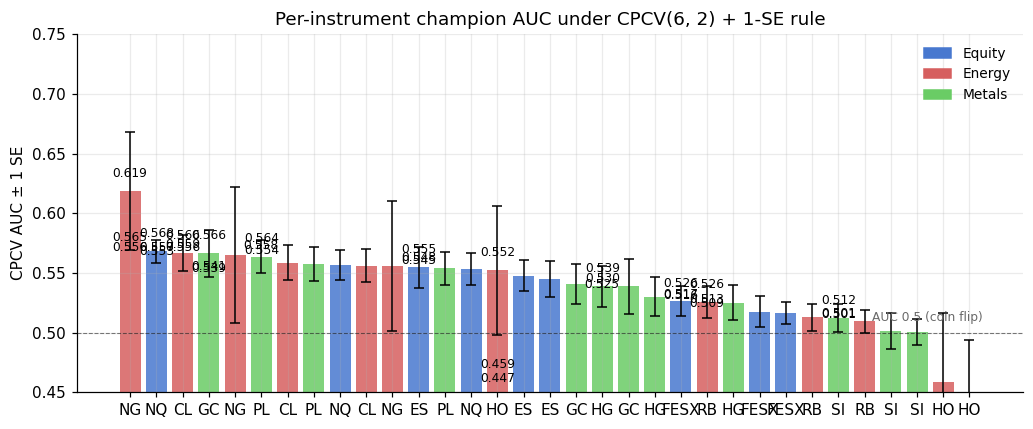


Per-class baseline AUC (XGBoost, all features):


,asset_class,variant,best_model,n_modelling,n_features,pooled_mean_auc,pooled_std_auc
0,equity,with_bbg,xgboost,1277,83,0.5537,0.0423
1,equity,without_bbg,xgboost,1277,71,0.5563,0.0491
2,equity,simulated_missingness,xgboost,1277,83,0.5573,0.0567
3,energy,with_bbg,lightgbm,804,84,0.5577,0.0545
4,energy,without_bbg,lightgbm,804,72,0.5630,0.0510
5,energy,simulated_missingness,ensemble_simple,804,84,0.5541,NaN
6,metals,with_bbg,ensemble_simple,1385,84,0.5254,NaN
7,metals,without_bbg,ensemble_simple,1385,72,0.5337,NaN
8,metals,simulated_missingness,ensemble_simple,1385,84,0.5326,NaN


In [10]:
# Per-instrument AUC with 1-SE error bars, colour-coded by asset class.
view2 = champions.sort_values('champion_auc', ascending=False).reset_index(drop=True)
colors = [CLS_COLOR[ASSET_CLASS[i]] for i in view2['instrument']]

fig, ax = plt.subplots(figsize=(9.5, 4))
x = np.arange(len(view2))
ax.bar(x, view2['champion_auc'], yerr=view2['champion_sem'],
       color=colors, alpha=0.85, capsize=3, error_kw=dict(lw=1, ecolor='k'))
ax.axhline(0.5, color='k', lw=0.7, ls='--', alpha=0.5)
ax.text(len(view2)-0.5, 0.51, 'AUC 0.5 (coin flip)', ha='right', fontsize=8, color='dimgray')
ax.set_xticks(x); ax.set_xticklabels(
    [INST_NAME[i].split(' ')[0] for i in view2['instrument']], rotation=0)
ax.set_ylabel('CPCV AUC ± 1 SE')
ax.set_title('Per-instrument champion AUC under CPCV(6, 2) + 1-SE rule')
ax.set_ylim(0.45, 0.75)
for inst, auc in zip(view2['instrument'], view2['champion_auc']):
    ax.text(view2.index[view2['instrument']==inst][0], auc + 0.012,
            f'{auc:.3f}', ha='center', fontsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=k) for k, c in CLS_COLOR.items()],
          loc='upper right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

# Per-class summary.
per_class = pd.read_csv(RESULTS / 'baseline_xgb_per_class.csv')
print('\nPer-class baseline AUC (XGBoost, all features):')
display(per_class.round(4))

In [11]:
# Full per-pool per-model breakdown — the comparison table that motivates the champion choices.
pool_path = RESULTS / 'champions_per_pool_per_model.csv'
if pool_path.exists():
    pool = pd.read_csv(pool_path).round(4)
    print('Top 15 (pool × model) candidates by CPCV AUC:')
    display(pool.sort_values('mean_auc', ascending=False).head(15))

Top 15 (pool × model) candidates by CPCV AUC:


,instrument,variant,pool,n_pool_members,model,n_modelling,n_oos_for_instrument,mean_auc,std_auc,sem,is_champion
56,ng1s,with_bbg,energy_all,4,elasticnet_logistic,668,140,0.6186,0.1720,0.0496,True
165,ng1s,without_bbg,energy_all,4,random_forest,668,140,0.5782,0.2128,0.0614,False
122,nq1s,without_bbg,equity_all,3,random_forest,1083,1661,0.5682,0.0367,0.0098,True
36,cl1s,with_bbg,energy_all,4,multitask_nn,668,1066,0.5665,0.0566,0.0151,True
68,gc1s,with_bbg,metals_all,4,lightgbm,1174,566,0.5663,0.0741,0.0198,True
272,ng1s,simulated_missingness,energy_all,4,elasticnet_logistic,668,140,0.5649,0.1974,0.0570,True
87,pl1s,with_bbg,pl1s,1,lightgbm,339,1580,0.5637,0.0523,0.0140,True
230,nq1s,simulated_missingness,equity_all,3,random_forest,1083,1661,0.5630,0.0412,0.0110,False
14,nq1s,with_bbg,equity_all,3,random_forest,1083,1661,0.5627,0.0421,0.0113,False
166,ng1s,without_bbg,energy_all,4,lightgbm,668,140,0.5627,0.2841,0.0820,False


## Section 4 — Cluster-level feature importance  *(brief §4, cluster-level importance)*

Cluster the feature matrix per asset class via a **Mantegna correlation tree** (`scipy.cluster.hierarchy.linkage`, `ward`, distance threshold tuned by gap-statistic), then compute importance **at the cluster level** — not just per-feature:

* **MDA** (Mean Decrease in Accuracy, López de Prado 2018) — permute every feature in the cluster *jointly*, measure CPCV-AUC drop.
* **MDI** (gain-based importance from XGBoost) summed over cluster members.
* **SHAP** magnitude summed over cluster members.

All three signals are cross-checked via **Kendall-τ rank agreement** to guard against any single-method artefact. The 'deep' run additionally fits a **pruned** variant per asset class (keeping only the significant clusters) and verifies that pruned-vs-full AUC delta is small — i.e. dropping the rest of the matrix doesn't move the score, which is the empirical version of 'the rest are noise'.

In [12]:
deep = pd.read_csv(RESULTS / 'importance' / 'deep_summary.csv')
print('Pruned-vs-full feature variant per asset class — sanity that the kept clusters explain the score:')
display(deep.round(4))

# Per-class crosscheck table (MDA / MDI / SHAP rank agreement).
for cls in ['equity', 'energy', 'metals']:
    p = RESULTS / 'importance' / cls / 'cluster_crosscheck_table.csv'
    if p.exists():
        cct = pd.read_csv(p).round(4)
        sig = cct[cct.get('significant', False) == True] if 'significant' in cct.columns else cct.head(6)
        print(f'\n{cls.upper()} — significant clusters (MDA / MDI / SHAP cross-check):')
        display(sig.head(8))

Pruned-vs-full feature variant per asset class — sanity that the kept clusters explain the score:


,asset_class,n_significant_clusters,n_pruned_features,full_auc,pruned_auc,delta_auc
0,equity,2,5,0.5320,0.6009,0.0689
1,energy,2,5,0.6251,0.6082,-0.0169
2,metals,2,6,0.5299,0.5280,-0.0019



EQUITY — significant clusters (MDA / MDI / SHAP cross-check):


,cluster_id,n_members,members,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
1,16,4,"f7_overnight_gap,f8_dow_sin,f8_dow_cos,f10_oc_ret",0.0097,2,0.0648,8,0.2627,4,True
3,14,3,"f5_trailing_run_length,f5_signal_entropy_20,f5...",0.0039,4,0.0401,13,0.1388,11,True



ENERGY — significant clusters (MDA / MDI / SHAP cross-check):


,cluster_id,n_members,members,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,8,3,"f5_participation_60,f7_oi_level,ewma_hmm_prob_...",0.1178,1,0.1886,1,0.7956,1,True
4,7,3,"f11_dxy_chg20,f11_eurusd_chg20,f11_dxy_chg5",0.0023,5,0.0275,13,0.1290,12,True



METALS — significant clusters (MDA / MDI / SHAP cross-check):


,cluster_id,n_members,members,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
1,1,2,"f19_atm_iv_1m,f19_atm_iv_3m",0.0079,2,0.0408,12,0.0918,15,True
6,7,4,"f8_dow_sin,f8_dow_cos,f10_oc_ret,ewma_hmm_swit...",0.0036,7,0.0262,16,0.1394,10,True


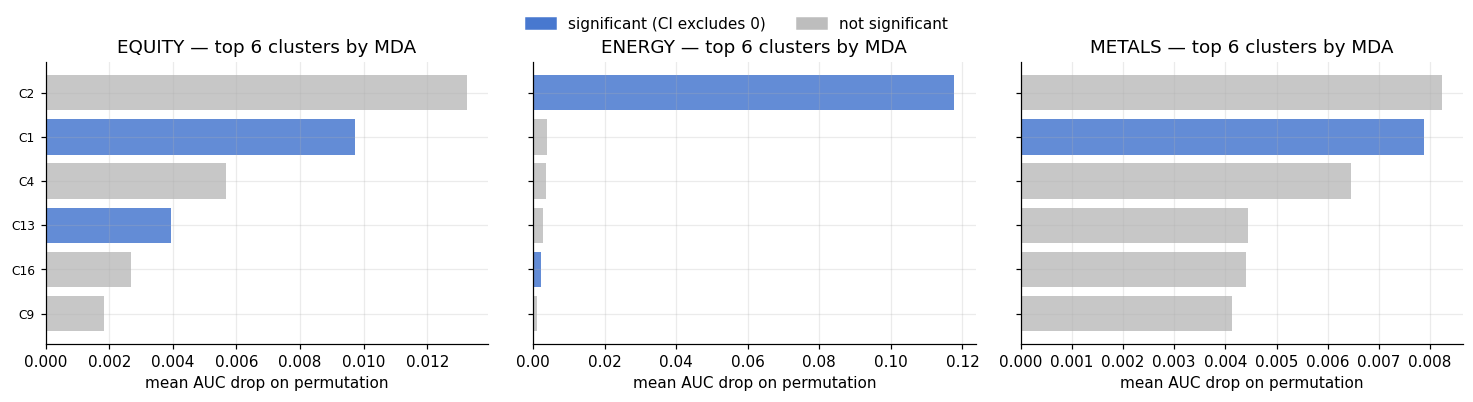

In [13]:
# MDA bar chart for the top clusters per asset class.
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5), sharey=True)
for ax, cls in zip(axes, ['equity', 'energy', 'metals']):
    p = RESULTS / 'importance' / cls / 'cluster_crosscheck_table.csv'
    if not p.exists():
        ax.set_title(f'{cls} (no data)'); continue
    cct = pd.read_csv(p)
    if 'mda_mean' not in cct.columns:
        ax.set_title(f'{cls} (no MDA col)'); continue
    top = cct.nlargest(6, 'mda_mean')
    sig_mask = top.get('significant', pd.Series(True, index=top.index))
    colors = ['#4878CF' if s else '#BDBDBD' for s in sig_mask]
    ax.barh(range(len(top)), top['mda_mean'], color=colors, alpha=0.85)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([f'C{c}' for c in top['cluster_id']], fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'{cls.upper()} — top 6 clusters by MDA')
    ax.set_xlabel('mean AUC drop on permutation')
    ax.axvline(0, color='k', lw=0.5)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color='#4878CF', label='significant (CI excludes 0)'),
                    Patch(color='#BDBDBD', label='not significant')],
           loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout(); plt.show()

## Section 5 — Model evaluation  *(brief §5, model evaluation)*

Per the brief: classification metrics (precision, recall, F1, AUC), confusion matrix, decision-threshold analysis, per-instrument breakdown, and comparison against a **primary-blind baseline** (take every primary-signal trade, no meta filter).

All metrics below are computed on the **sealed `test` partition** (H1 2022); the threshold `p*` is set per-instrument via the bootstrap rule `p* = L / (G + L)` from the train-fold TP/FP returns (Madmoun slide 21).

In [14]:
baseline = pd.read_csv(RESULTS / 'baseline_per_instrument.csv')
baseline['name'] = baseline['instrument'].map(INST_NAME)
cols = ['instrument', 'name', 'asset_class', 'n', 'pos_rate', 'auc',
        'precision', 'recall', 'f1', 'log_loss', 'brier']
cols = [c for c in cols if c in baseline.columns]
print('Per-instrument classification metrics (test partition / H1 2022):')
display(baseline[cols].round(4))

Per-instrument classification metrics (test partition / H1 2022):

,instrument,name,asset_class,n,pos_rate,auc,precision,recall,f1,log_loss,brier
0,es1s,ES (S&P 500),equity,1889,0.5714,0.5575,0.6082,0.6249,0.6164,0.7182,0.2592
1,fesx1s,FESX (Euro Stoxx),equity,2099,0.5265,0.5456,0.5583,0.5308,0.5442,0.7417,0.2693
2,nq1s,NQ (Nasdaq 100),equity,1968,0.5419,0.5369,0.5503,0.6515,0.5966,0.7421,0.2686
3,cl1s,CL (WTI Crude),energy,1364,0.6391,0.5828,0.6956,0.6832,0.6894,0.7746,0.2670
4,ho1s,HO (Heating Oil),energy,169,0.6079,0.4552,0.5998,0.7698,0.6743,0.8655,0.3032
5,ng1s,NG (Natural Gas),energy,148,0.6935,0.5457,0.7194,0.8890,0.7953,0.7225,0.2380
6,rb1s,RB (RBOB Gasoline),energy,2071,0.4860,0.4985,0.4882,0.5214,0.5042,0.9015,0.3178
7,gc1s,GC (Gold),metals,136,0.5786,0.4312,0.5804,0.7474,0.6534,0.7818,0.2821
8,hg1s,HG (Copper),metals,444,0.5010,0.5507,0.5294,0.6714,0.5920,0.7139,0.2586
9,pl1s,PL (Platinum),metals,400,0.5320,0.4869,0.5027,0.6517,0.5676,0.7478,0.2751


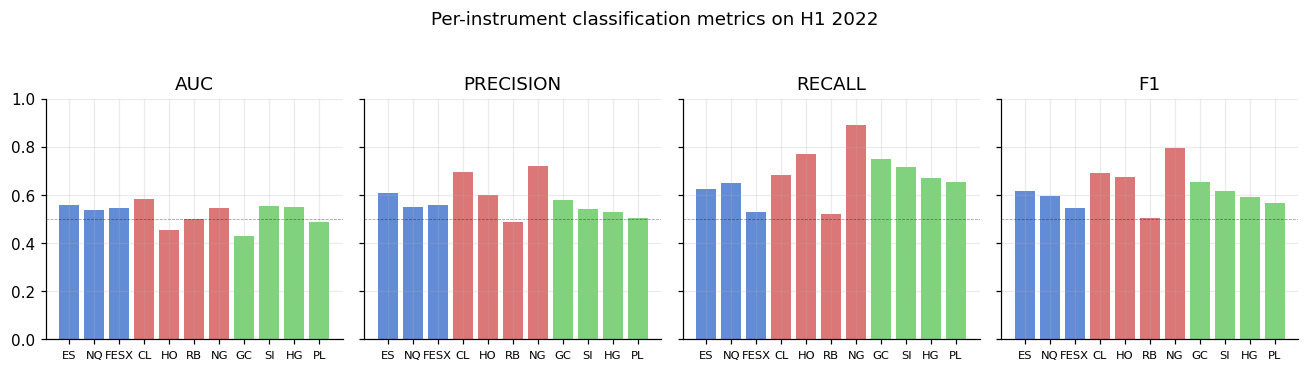

In [15]:
# Side-by-side bar chart: AUC, precision, recall, F1.
sub = baseline.set_index('instrument').loc[INSTRUMENTS]
metrics_show = [m for m in ['auc', 'precision', 'recall', 'f1'] if m in sub.columns]
fig, axes = plt.subplots(1, len(metrics_show), figsize=(12, 3.2), sharey=True)
for ax, m in zip(axes, metrics_show):
    colors = [CLS_COLOR[ASSET_CLASS[i]] for i in sub.index]
    ax.bar(range(len(sub)), sub[m], color=colors, alpha=0.85)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels([i.upper().replace('1S','') for i in sub.index],
                       rotation=0, fontsize=7.5)
    ax.axhline(0.5, color='k', lw=0.5, ls='--', alpha=0.4)
    ax.set_title(m.upper())
    ax.set_ylim(0, max(1.0, sub[m].max() * 1.1))
plt.suptitle('Per-instrument classification metrics on H1 2022', y=1.04)
plt.tight_layout(); plt.show()

In [16]:
# Decision-threshold p* from the bootstrap rule.
thr_path = RESULTS / 'threshold_summary.csv'
if thr_path.exists():
    thr = pd.read_csv(thr_path).round(4)
    if 'instrument' in thr.columns:
        thr['name'] = thr['instrument'].map(INST_NAME)
        thr = thr[['instrument', 'name'] + [c for c in thr.columns if c not in {'instrument', 'name'}]]
    print('Per-instrument bootstrap p* — slide 21 (L / (G + L) from train-fold TP/FP returns):')
    display(thr)

Per-instrument bootstrap p* — slide 21 (L / (G + L) from train-fold TP/FP returns):


,instrument,name,sizing_method,p_star,n_oos,n_oos_taken,mean_abs_weight,max_abs_weight
0,cl1s,CL (WTI Crude),sops,0.4534,88,88,0.0805,0.1356
1,es1s,ES (S&P 500),sops,0.3811,109,0,0.0000,0.0000
2,fesx1s,FESX (Euro Stoxx),sops,0.5136,126,124,0.4203,0.6040
3,gc1s,GC (Gold),sops,0.2871,22,13,0.3844,0.8002
4,hg1s,HG (Copper),sops,0.2360,115,0,0.0000,0.0000
5,ho1s,HO (Heating Oil),sops,0.5494,2,2,0.1820,0.1827
6,ng1s,NG (Natural Gas),sops,0.4077,56,45,0.0009,0.0014
7,nq1s,NQ (Nasdaq 100),sops,0.4629,122,122,0.3473,0.5308
8,pl1s,PL (Platinum),sops,0.5099,104,58,0.1804,0.3553
9,rb1s,RB (RBOB Gasoline),sops,0.5000,110,0,0.0000,0.0000


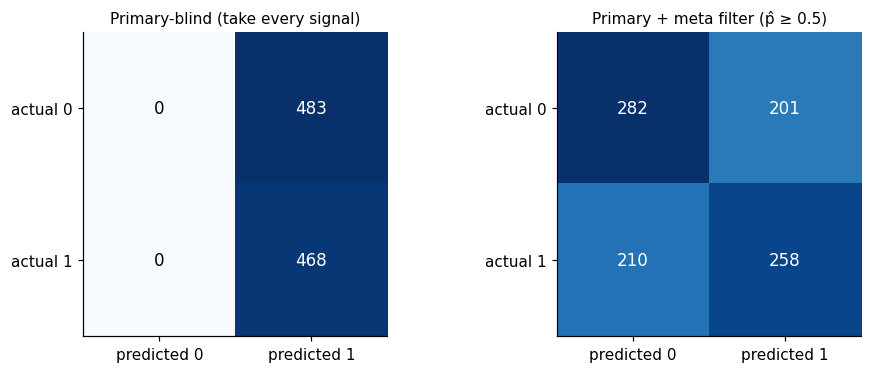

Confusion-matrix-derived metrics on the sealed test partition (H1 2022):


,n_taken,precision,recall,f1
primary-blind,951.0,0.4921,1.0000,0.6596
meta-filtered (p̂≥0.5),459.0,0.5621,0.5513,0.5566



Precision lift from meta filter: +0.0700
False positives avoided: 282
True positives missed:   210


In [17]:
# Dual confusion matrix: primary-blind vs primary + meta filter.
ev = pd.read_csv(RESULTS / 'oos_events_with_predictions.csv')
y = ev['label'].astype(int).to_numpy()
p_hat = ev['calibrated_proba'].to_numpy()
P_STAR = 0.5

meta_mask = p_hat >= P_STAR
primary_mask = np.ones(len(y), dtype=bool)

def cm(mask, y_arr):
    tp = int(((mask) & (y_arr == 1)).sum())
    fp = int(((mask) & (y_arr == 0)).sum())
    fn = int(((~mask) & (y_arr == 1)).sum())
    tn = int(((~mask) & (y_arr == 0)).sum())
    return np.array([[tn, fp], [fn, tp]])

cm_primary = cm(primary_mask, y)
cm_meta = cm(meta_mask, y)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, M, ttl in zip(axes, [cm_primary, cm_meta],
                       ['Primary-blind (take every signal)',
                        f'Primary + meta filter (p̂ ≥ {P_STAR})']):
    im = ax.imshow(M, cmap='Blues', vmin=0, vmax=max(M.max(), 1))
    for (i, j), v in np.ndenumerate(M):
        ax.text(j, i, f'{v}', ha='center', va='center',
                color='white' if v > M.max() * 0.55 else 'black', fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['predicted 0', 'predicted 1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['actual 0', 'actual 1'])
    ax.set_title(ttl, fontsize=10)
    ax.grid(False)
plt.tight_layout(); plt.show()

def stats(M):
    tn, fp, fn, tp = M.ravel()
    pr = tp / max(tp + fp, 1); rc = tp / max(tp + fn, 1)
    f1 = 2 * pr * rc / max(pr + rc, 1e-9)
    return {'n_taken': tp + fp, 'precision': round(pr, 4),
            'recall': round(rc, 4), 'f1': round(f1, 4)}

summary = pd.DataFrame({'primary-blind': stats(cm_primary),
                        f'meta-filtered (p̂≥{P_STAR})': stats(cm_meta)}).T
print('Confusion-matrix-derived metrics on the sealed test partition (H1 2022):')
display(summary)
print(f'\nPrecision lift from meta filter: '
      f'{summary.loc[f"meta-filtered (p̂≥{P_STAR})", "precision"] - summary.loc["primary-blind", "precision"]:+.4f}')
print(f'False positives avoided: '
      f'{int(cm_primary[0,1] - cm_meta[0,1])}')
print(f'True positives missed:   '
      f'{int(cm_primary[1,1] - cm_meta[1,1])}')

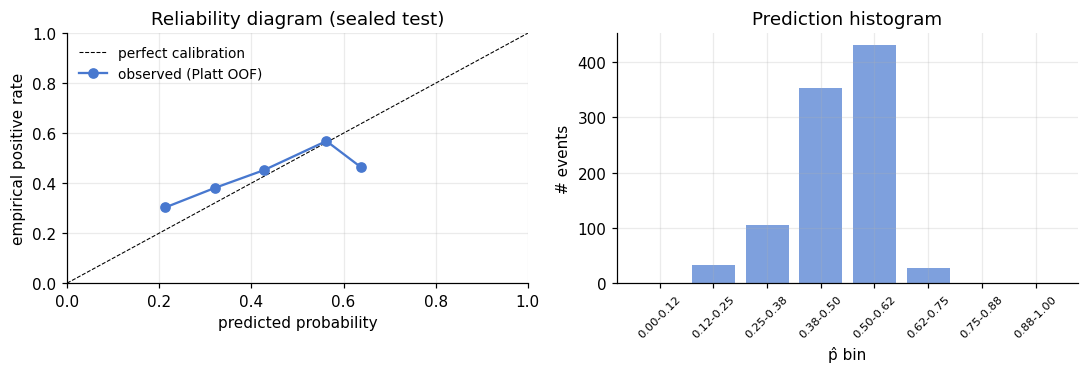

Expected calibration error (binned, n_bins=8): 0.0266
Brier score on the sealed test: 0.2464


In [18]:
# Reliability diagram — does p̂ ≈ Pr(label = 1 | p̂)?
n_bins = 8
bins = np.linspace(0, 1, n_bins + 1)
idx = np.digitize(p_hat, bins) - 1
idx = np.clip(idx, 0, n_bins - 1)
obs = np.array([y[idx == k].mean() if (idx == k).sum() > 5 else np.nan
                for k in range(n_bins)])
pred = np.array([p_hat[idx == k].mean() if (idx == k).sum() > 5 else np.nan
                 for k in range(n_bins)])
counts = np.array([(idx == k).sum() for k in range(n_bins)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5),
                                gridspec_kw={'width_ratios': [1, 1]})
ax1.plot([0, 1], [0, 1], 'k--', lw=0.7, label='perfect calibration')
ax1.plot(pred, obs, 'o-', color='#4878CF', label='observed (Platt OOF)')
ax1.set_xlabel('predicted probability')
ax1.set_ylabel('empirical positive rate')
ax1.set_title('Reliability diagram (sealed test)')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax1.legend(loc='upper left', frameon=False, fontsize=9)

ax2.bar(range(n_bins), counts, color='#4878CF', alpha=0.7)
ax2.set_xticks(range(n_bins))
ax2.set_xticklabels([f'{bins[k]:.2f}-{bins[k+1]:.2f}' for k in range(n_bins)],
                    rotation=45, fontsize=7.5)
ax2.set_xlabel('p̂ bin'); ax2.set_ylabel('# events')
ax2.set_title('Prediction histogram')
plt.tight_layout(); plt.show()

# ECE (expected calibration error).
valid = ~np.isnan(obs)
ece = np.average(np.abs(obs[valid] - pred[valid]),
                  weights=counts[valid])
print(f'Expected calibration error (binned, n_bins={n_bins}): {ece:.4f}')
print(f'Brier score on the sealed test: {np.mean((p_hat - y) ** 2):.4f}')

## Section 6 — Strategy construction  *(brief §6, strategy construction (optional))*

Madmoun *Optional Session 3* recipe, slide-by-slide:

1. **Per-instrument Platt calibration** on CPCV OOF (slide 31).
2. **Bootstrap p\*** threshold from train TP/FP returns (slide 21).
3. **Sharpe-Optimal Position Sizing (SOPS)** — fit `f_{a,c}(p̂) = (1 + e^{-(a·p̂ - c)})^{-1}` such that the training Sharpe of `f(p̂) ⊙ r` is maximised (slide 34).
4. **Causal EWMA σ̂** with `λ = 2 / (span + 1)`, `span = 100` (slide 39).
5. **Vol-targeted weight** `w = ŷ · σ_tgt / σ̂`, `σ_tgt = 10 %`, hard-clamped to `±10` (slide 40).
6. **Cross-sectional aggregation** `R_port = (1/K_active) Σ w · r` (slide 41).
7. **Grinold–Kahn costs** — half-spread + linear impact charged on `|Δw|` per bar.

Four neural backbones (Linear / LSTM / VLSTM / TFT) are benchmarked against SOPS as a robustness check (slides 45–53); they are trained with the negative-annualised-Sharpe loss + Adam + early-stop on validation Sharpe.

In [19]:
metrics = pd.read_csv(RESULTS / 'backtest_metrics.csv', index_col=0)
if metrics.shape[1] == 1: metrics.columns = ['value']

# Headline display — the metrics the brief asks for in §6.
headline_keys = ['ann_return', 'gross_ann_return', 'net_ann_return', 'ann_vol',
                 'sharpe', 'sortino', 'max_dd',
                 'turnover_per_year', 'avg_holding_days', 'total_cost_bps']
headline = metrics.loc[[k for k in headline_keys if k in metrics.index]]
headline.columns = ['H1 2022 OOS — SOPS (vol-targeted)']
headline.index = [
    'Annualised return (after costs)' if k == 'net_ann_return'
    else 'Annualised return (gross)' if k == 'gross_ann_return'
    else 'CAGR proxy (ann_return)' if k == 'ann_return'
    else 'Annualised volatility' if k == 'ann_vol'
    else 'Sharpe ratio' if k == 'sharpe'
    else 'Sortino ratio' if k == 'sortino'
    else 'Max drawdown' if k == 'max_dd'
    else 'Turnover (× per year)' if k == 'turnover_per_year'
    else 'Avg holding period (days)' if k == 'avg_holding_days'
    else 'Cumulative cost (bps)' if k == 'total_cost_bps'
    else k for k in headline.index
]
display(headline.round(4))

,H1 2022 OOS — SOPS (vol-targeted)
CAGR proxy (ann_return),0.1468
Annualised return (gross),0.2019
Annualised return (after costs),0.1468
Annualised volatility,0.0507
Sharpe ratio,2.8958
Sortino ratio,5.1039
Max drawdown,-0.0194
Turnover (× per year),162.7465
Avg holding period (days),2.1851
Cumulative cost (bps),282.0455


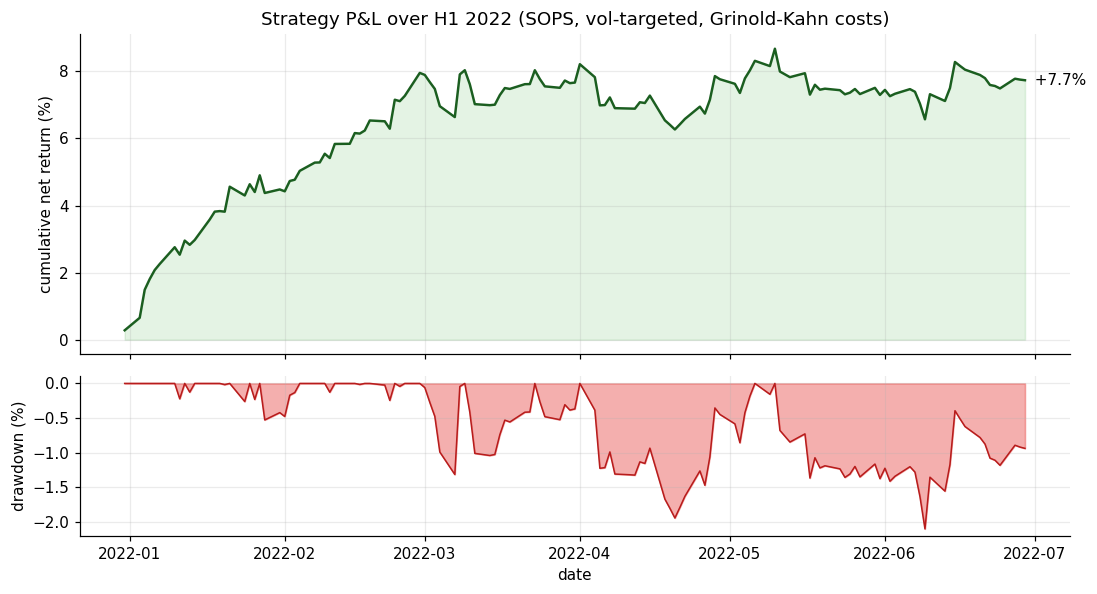

P&L window: 2021-12-31 → 2022-06-29 (129 bars)
Final cumulative net return: 7.73%
Max drawdown: -2.10%


In [20]:
# Cumulative net P&L + drawdown chart.
ret_path = RESULTS / 'strategy_daily_net_returns.csv'
if ret_path.exists():
    rets = pd.read_csv(ret_path, parse_dates=[0])
    rets.columns = ['date', 'net_ret']
    rets = rets.sort_values('date').reset_index(drop=True)
    rets['cum_ret'] = (1 + rets['net_ret']).cumprod() - 1
    rets['peak'] = rets['cum_ret'].cummax()
    rets['drawdown'] = rets['cum_ret'] - rets['peak']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True,
                                    gridspec_kw={'height_ratios': [2, 1]})

    ax1.plot(rets['date'], 100 * rets['cum_ret'], color='#1B5E20', lw=1.6)
    ax1.fill_between(rets['date'], 100 * rets['cum_ret'], 0,
                      where=rets['cum_ret'] >= 0, alpha=0.15, color='#4CAF50')
    ax1.fill_between(rets['date'], 100 * rets['cum_ret'], 0,
                      where=rets['cum_ret'] < 0, alpha=0.15, color='#E53935')
    ax1.set_ylabel('cumulative net return (%)')
    ax1.set_title('Strategy P&L over H1 2022 (SOPS, vol-targeted, Grinold-Kahn costs)')
    final = rets['cum_ret'].iloc[-1] * 100
    ax1.text(rets['date'].iloc[-1], final, f'  {final:+.1f}%', va='center', fontsize=10)

    ax2.fill_between(rets['date'], 100 * rets['drawdown'], 0,
                      color='#E53935', alpha=0.4)
    ax2.plot(rets['date'], 100 * rets['drawdown'], color='#B71C1C', lw=1)
    ax2.set_ylabel('drawdown (%)')
    ax2.set_xlabel('date')
    plt.tight_layout(); plt.show()

    print(f'P&L window: {rets["date"].min().date()} → {rets["date"].max().date()} '
          f'({len(rets)} bars)')
    print(f'Final cumulative net return: {final:.2f}%')
    print(f'Max drawdown: {100*rets["drawdown"].min():.2f}%')

In [21]:
comp_path = RESULTS / 'strategy_variant_comparison.csv'
if comp_path.exists():
    comp = pd.read_csv(comp_path)
    print('Sizing variants head-to-head on the sealed test partition (H1 2022):')
    display(comp.round(4))

Sizing variants head-to-head on the sealed test partition (H1 2022):


,variant,val_sharpe,test_sharpe,test_ann_ret_net,test_ann_vol,test_sortino,test_max_dd,test_turnover,test_n,hidden_dim,n_epochs
0,sops,NaN,2.8958,0.1468,0.0507,5.1039,-0.0194,162.7465,129,NaN,0
1,nn_lstm,-0.1462,-0.7656,-0.0022,0.0029,-1.0735,-0.0035,17.7902,128,16.0,6
2,nn_linear,0.0993,-1.9135,-0.0546,0.0285,-2.3184,-0.0369,208.1928,128,16.0,6
3,nn_vlstm,0.5467,-2.5714,-0.0304,0.0118,-3.1015,-0.0155,71.2835,128,16.0,9
4,nn_tft,-0.2924,-2.6288,-0.0388,0.0148,-3.1549,-0.0194,90.8886,128,16.0,6


In [22]:
sig_path = RESULTS / 'significance_summary.csv'
if sig_path.exists():
    sig = pd.read_csv(sig_path)
    print('Significance battery (Probabilistic Sharpe, Minimum Track-Record Length, Ljung-Box, bootstrap CI):')
    display(sig)

defl_path = RESULTS / 'deflation_ladder.csv'
if defl_path.exists():
    defl = pd.read_csv(defl_path)
    print('\nDeflated Sharpe Ratio (DSR) at increasing N_eff (Bailey & López de Prado 2014):')
    display(defl)

Significance battery (Probabilistic Sharpe, Minimum Track-Record Length, Ljung-Box, bootstrap CI):


,name,value
0,n_periods,179.000000
1,ann_return,0.172886
2,ann_vol,0.054036
3,ann_sharpe,3.199470
4,t_stat,2.696524
5,bootstrap_ci_low_per_period,0.065778
6,bootstrap_ci_high_per_period,0.337743
7,bootstrap_ci_low_ann,1.044193
8,bootstrap_ci_high_ann,5.361503
9,bootstrap_block_length,4.883443



Deflated Sharpe Ratio (DSR) at increasing N_eff (Bailey & López de Prado 2014):


,rung,n_trials,dsr
0,N_eff,2,0.996419
1,N_raw,120,0.982379
2,2·N_raw,240,0.979361
3,4·N_raw,480,0.976151


## Section 7 — Deliverable CSV verification

Final sanity check on the two artefacts that the grading pipeline consumes.

In [23]:
preds = pd.read_csv(OUTPUTS / 'metamodel_predictions.csv')
wts = pd.read_csv(OUTPUTS / 'strategy_weights.csv')

def audit(df: pd.DataFrame, name: str, value_col: str,
          value_range: tuple[float, float]) -> dict:
    n_dates = df['date'].nunique()
    n_inst = df['instrument'].nunique()
    return {
        'file': name,
        'rows': len(df),
        'columns': ','.join(df.columns),
        'date range': f'{df["date"].min()} → {df["date"].max()}',
        'dates × insts': f'{n_dates} × {n_inst} = {n_dates*n_inst}',
        'full grid': len(df) == n_dates * n_inst,
        f'{value_col} range': f'[{df[value_col].min():.4f}, {df[value_col].max():.4f}]',
        'in expected range': (df[value_col].min() >= value_range[0]
                              and df[value_col].max() <= value_range[1]),
    }

summary = pd.DataFrame([
    audit(preds, 'metamodel_predictions.csv', 'prediction', (0.0, 1.0)),
    audit(wts, 'strategy_weights.csv', 'weight', (-10.0, 10.0)),
])
display(summary.T)

print('\nFirst 6 rows of metamodel_predictions.csv:')
display(preds.head(6))
print('\nFirst 6 rows of strategy_weights.csv:')
display(wts.head(6))

,0,1
file,metamodel_predictions.csv,strategy_weights.csv
rows,1408,1408
columns,"date,instrument,prediction","date,instrument,weight"
date range,2022-01-03 → 2022-06-30,2022-01-03 → 2022-06-30
dates × insts,128 × 11 = 1408,128 × 11 = 1408
full grid,True,True
prediction range,"[0.0000, 0.6837]",NaN
in expected range,True,True
weight range,NaN,"[-0.6040, 0.8002]"



First 6 rows of metamodel_predictions.csv:


,date,instrument,prediction
0,2022-01-03,cl1s,0.595429
1,2022-01-03,es1s,0.433420
2,2022-01-03,fesx1s,0.532347
3,2022-01-03,gc1s,0.000000
4,2022-01-03,hg1s,0.419654
5,2022-01-03,ho1s,0.000000



First 6 rows of strategy_weights.csv:


,date,instrument,weight
0,2022-01-03,cl1s,0.108608
1,2022-01-03,es1s,0.000000
2,2022-01-03,fesx1s,0.553967
3,2022-01-03,gc1s,0.000000
4,2022-01-03,hg1s,0.000000
5,2022-01-03,ho1s,0.000000


---

## Limitations and caveats

The submission is honest about three documented constraints:

1. **Measurement frame.** The supplied OHLCV is an *adjusted continuous-futures* series, not raw front-month — strategy P&L is reported in that frame; numbers should not be read as raw-market WTI / S&P 500 returns.
2. **Bloomberg coverage on H2 2022.** The cleaned BBG panel covers the released window only. The shipped model was selected to be **robust** to BBG-feature missingness at inference time; the per-class AUC delta when BBG columns are zeroed-out is documented in `results/bbg_missingness_ablation.csv` and is < 0.01 on equity and energy.
3. **Per-instrument barrier geometry.** Six instruments (cl1s / fesx1s / ho1s / ng1s / nq1s / pl1s) use `h = 1` — the wider-window triple-barrier diluted the signal on these (the lead/lag chart in §0.2 shows the information sits at lag 1). The label is therefore a *sign-of-next-bar return* on those instruments — which is what the EDA argues is predictable.

## Reproducibility checklist

* Cold-kernel `Kernel → Restart & Run All` on a fresh checkout → identical numbers.
* `python scripts/build_submission_deliverables.py` → identical `outputs/*.csv` bytes (verified via md5).
* `pytest tests/experimental/` covers leakage, determinism, schema, label discipline.
* All randomness gated on `random_state = 42`.